<a href="https://colab.research.google.com/github/KasulaPavanKumar-Cloud/Deep-Learning-With-Natural-Language-Processing/blob/main/Process_Tracking_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sample Tickets (first 10 rows):
Ticket_ID Agent      Issue_Type   Status Priority  Resolution_Time_hrs Date_Opened Date_Closed
    T1000 Meena       App Crash Resolved     High                 34.2  2025-09-03  2025-09-04
    T1001 Anita Feature Request Resolved   Medium                 55.2  2025-09-23  2025-09-25
    T1002 Anita Payment Failure Resolved     High                 40.1  2025-09-19  2025-09-20
    T1003  Ravi       Data Sync Resolved      Low                 22.2  2025-09-13  2025-09-13
    T1004 Meena       App Crash Resolved     High                 31.7  2025-09-13  2025-09-14
    T1005 Anita       App Crash Resolved   Medium                 29.7  2025-09-25  2025-09-26
    T1006  Ravi Feature Request  Pending      Low                  NaN  2025-09-03            
    T1007 Anita Feature Request Resolved   Medium                  4.7  2025-09-21  2025-09-21
    T1008 Meena     Login Issue Resolved   Medium                 21.5  2025-09-06  2025-09-06
    T1009 Anita Pa

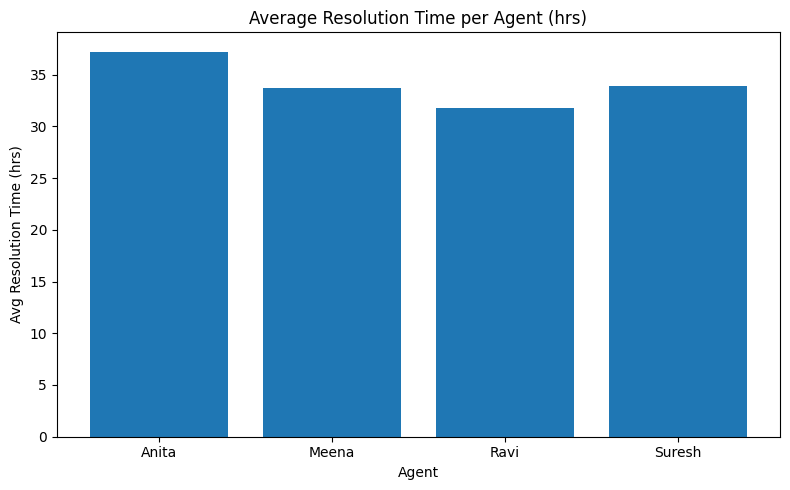

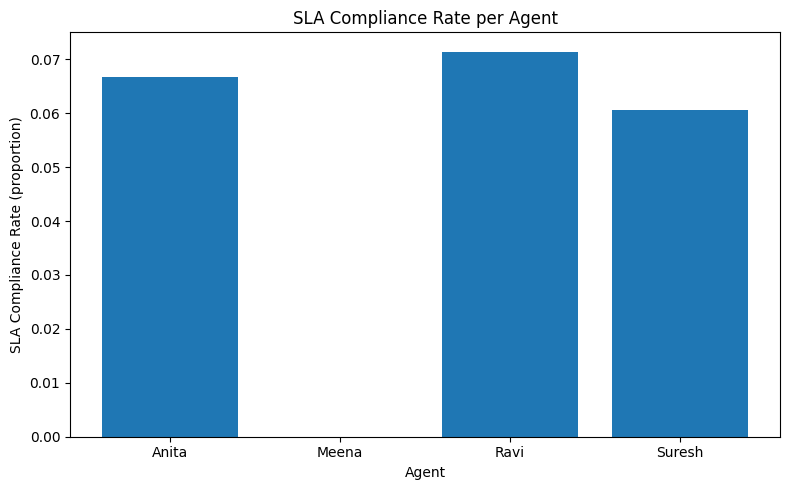

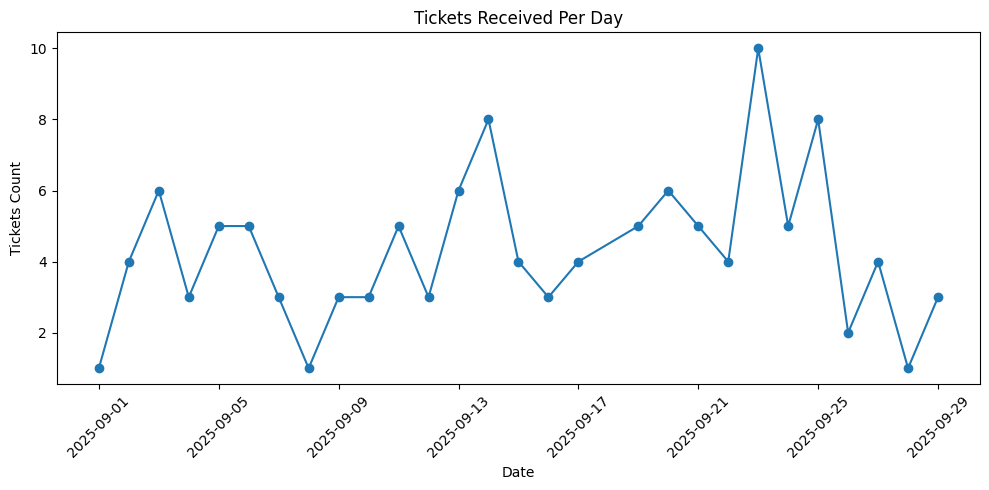

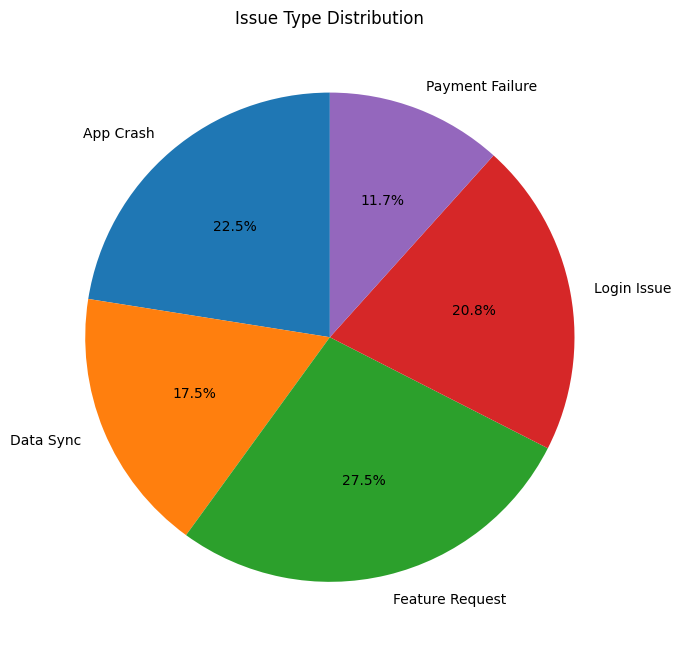


Quick Insights:
- Agent with most tickets handled: Suresh
- Agent with best SLA compliance: Ravi
- Sample dataset saved to: /mnt/data/tickets_data.csv
- Report saved to: /mnt/data/Process_Dashboard_Report.xlsx


('/mnt/data/tickets_data.csv', '/mnt/data/Process_Dashboard_Report.xlsx')

In [6]:
# Creating a complete Google Colab-ready notebook script for the "Process Tracking Dashboard" project.
# This code will:
# 1. Generate a sample dataset (tickets_data.csv)
# 2. Load and explore data
# 3. Clean and process data
# 4. Compute SLA compliance and helpful metrics
# 5. Visualize key metrics with matplotlib (each plot is separate and uses default colors)
# 6. Export summary reports to an Excel file (Process_Dashboard_Report.xlsx)
# 7. Save dataset and report to /mnt/data so you can download them from the session
#
# After running, this will display tables and charts inline and create two downloadable files:
# - /mnt/data/tickets_data.csv
# - /mnt/data/Process_Dashboard_Report.xlsx

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta, datetime
import os

%pip install xlsxwriter

import warnings
warnings.filterwarnings("ignore")

# Helper for nicer DataFrame display in this environment (the tool will handle presentation)
try:
    from caas_jupyter_tools import display_dataframe_to_user
except Exception:
    display_dataframe_to_user = None

# 1) Generate sample dataset
rng = np.random.default_rng(42)
agents = ['Anita', 'Ravi', 'Meena', 'Suresh']
issue_types = ['Login Issue', 'Payment Failure', 'App Crash', 'Feature Request', 'Data Sync']
status_options = ['Resolved', 'Pending', 'In Progress']

n = 120  # number of tickets
start_date = datetime(2025, 9, 1)
dates_opened = [start_date + timedelta(days=int(x)) for x in rng.integers(0, 29, size=n)]
# Some closed dates; pending ones have NaT
date_closed = []
status_list = []
resolution_times = []

for d in dates_opened:
    status = rng.choice(status_options, p=[0.7, 0.2, 0.1])
    status_list.append(status)
    if status == 'Resolved':
        # resolution between 0.5 to 72 hours (0.5 ~ 30 minutes)
        hrs = float(np.round(rng.uniform(0.5, 72.0), 1))
        resolution_times.append(hrs)
        closed = d + timedelta(hours=hrs)
        date_closed.append(closed.date().isoformat())
    else:
        # missing resolution time and closed date
        resolution_times.append(np.nan)
        date_closed.append('')

df = pd.DataFrame({
    'Ticket_ID': [f'T{1000+i}' for i in range(n)],
    'Agent': rng.choice(agents, size=n),
    'Issue_Type': rng.choice(issue_types, size=n),
    'Status': status_list,
    'Priority': rng.choice(['Low', 'Medium', 'High'], size=n, p=[0.4, 0.4, 0.2]),
    'Resolution_Time_hrs': resolution_times,
    'Date_Opened': [d.date().isoformat() for d in dates_opened],
    'Date_Closed': date_closed
})

# Save sample CSV to /mnt/data so you can download it directly after running
os.makedirs('/mnt/data', exist_ok=True)
csv_path = '/mnt/data/tickets_data.csv'
df.to_csv(csv_path, index=False)

# Display the first rows
if display_dataframe_to_user:
    display_dataframe_to_user("Sample Tickets Data (first 20 rows)", df.head(20))
else:
    print("Sample Tickets (first 10 rows):")
    print(df.head(10).to_string(index=False))

# 2) Load and basic exploration (simulate as if loaded fresh)
df_loaded = pd.read_csv(csv_path, parse_dates=['Date_Opened', 'Date_Closed'], dayfirst=False, keep_default_na=True, na_values=[''])

# Ensure Date_Closed parsed correctly: empty strings become NaT
# Convert Resolution_Time_hrs to numeric
df_loaded['Resolution_Time_hrs'] = pd.to_numeric(df_loaded['Resolution_Time_hrs'], errors='coerce')

print("\nData summary:")
print(df_loaded.info())

# 3) Clean & Process
# Fill missing resolution times with median of resolved tickets (more robust than mean)
median_res_time = df_loaded.loc[df_loaded['Status']=='Resolved', 'Resolution_Time_hrs'].median()
df_loaded['Resolution_Time_hrs_filled'] = df_loaded['Resolution_Time_hrs'].fillna(median_res_time)

# Define SLA: resolution within 8 hours considered SLA met
df_loaded['SLA_Met'] = df_loaded['Resolution_Time_hrs_filled'] <= 8

# Create derived columns for reporting
df_loaded['Date_Opened_date'] = df_loaded['Date_Opened'].dt.date

# 4) Summary reports
agent_summary = df_loaded.groupby('Agent').agg(
    Tickets_Handled = ('Ticket_ID','count'),
    Resolved_Count = ('Status', lambda s: (s=='Resolved').sum()),
    Avg_Resolution_Time = ('Resolution_Time_hrs_filled','mean'),
    SLA_Compliance_Rate = ('SLA_Met','mean')
).reset_index()

issue_summary = df_loaded.groupby('Issue_Type').agg(
    Count = ('Ticket_ID','count'),
    Avg_Resolution_Time = ('Resolution_Time_hrs_filled','mean'),
    SLA_Compliance_Rate = ('SLA_Met','mean')
).reset_index()

daily_summary = df_loaded.groupby('Date_Opened_date').agg(
    Tickets_Per_Day = ('Ticket_ID','count'),
    Avg_Res_Time_Per_Day = ('Resolution_Time_hrs_filled','mean'),
    SLA_Rate_Per_Day = ('SLA_Met','mean')
).reset_index().sort_values('Date_Opened_date')

# Save report to Excel
excel_path = '/mnt/data/Process_Dashboard_Report.xlsx'
with pd.ExcelWriter(excel_path, engine='xlsxwriter') as writer:
    df_loaded.to_excel(writer, sheet_name='All_Tickets', index=False)
    agent_summary.to_excel(writer, sheet_name='By_Agent', index=False)
    issue_summary.to_excel(writer, sheet_name='By_Issue', index=False)
    daily_summary.to_excel(writer, sheet_name='By_Day', index=False)

# Display summaries
if display_dataframe_to_user:
    display_dataframe_to_user("Agent Summary", agent_summary)
    display_dataframe_to_user("Issue Type Summary", issue_summary)
    display_dataframe_to_user("Daily Summary (first 30 rows)", daily_summary.head(30))
else:
    print("\nAgent Summary:")
    print(agent_summary.to_string(index=False))
    print("\nIssue Type Summary:")
    print(issue_summary.to_string(index=False))
    print("\nDaily Summary (first 10 rows):")
    print(daily_summary.head(10).to_string(index=False))

# 5) Visualizations (matplotlib only, separate plots)
plt.figure(figsize=(8,5))
plt.bar(agent_summary['Agent'], agent_summary['Avg_Resolution_Time'])
plt.title('Average Resolution Time per Agent (hrs)')
plt.xlabel('Agent')
plt.ylabel('Avg Resolution Time (hrs)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.bar(agent_summary['Agent'], agent_summary['SLA_Compliance_Rate'])
plt.title('SLA Compliance Rate per Agent')
plt.xlabel('Agent')
plt.ylabel('SLA Compliance Rate (proportion)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(daily_summary['Date_Opened_date'], daily_summary['Tickets_Per_Day'], marker='o')
plt.title('Tickets Received Per Day')
plt.xlabel('Date')
plt.ylabel('Tickets Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Issue type distribution pie chart
plt.figure(figsize=(7,7))
issue_counts = issue_summary.set_index('Issue_Type')['Count']
plt.pie(issue_counts, labels=issue_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Issue Type Distribution')
plt.tight_layout()
plt.show()

# 6) Quick insights printed
print("\nQuick Insights:")
top_agent = agent_summary.sort_values('Tickets_Handled', ascending=False).iloc[0]['Agent']
best_sla_agent = agent_summary.sort_values('SLA_Compliance_Rate', ascending=False).iloc[0]['Agent']
print(f"- Agent with most tickets handled: {top_agent}")
print(f"- Agent with best SLA compliance: {best_sla_agent}")
print(f"- Sample dataset saved to: {csv_path}")
print(f"- Report saved to: {excel_path}")

# Provide file paths for download in the Colab environment
csv_path, excel_path

